In [1]:
# Install/update necessary libraries
!pip install -U imbalanced-learn scikit-learn pandas

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import glob
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.pipeline import Pipeline

# ==========================================
# 1. Define Paths & Load Data (Colab Paths)
# ==========================================
# Updated to point to the Colab mounted Drive structure
attack_dir = '/content/drive/MyDrive/ECE1513/Project/iec104_pre-processed/attack-data/'
attack_free_dir = '/content/drive/MyDrive/ECE1513/Project/iec104_pre-processed/attack-free-data/'
dest_folder = '/content/drive/MyDrive/ECE1513/Project/post-treatment'

print("Loading raw data from Google Drive...")
all_files = glob.glob(os.path.join(attack_dir, "*.csv")) + glob.glob(os.path.join(attack_free_dir, "*.csv"))

if not all_files:
    print("WARNING: No CSV files found. Please double-check your folder paths.")
else:
    print(f"Found {len(all_files)} files. Concatenating...")

df_list = [pd.read_csv(file) for file in all_files]
df = pd.concat(df_list, ignore_index=True)

os.makedirs(dest_folder, exist_ok=True)
df = df.dropna()

# ==========================================
# 2. Categorical Feature Encoding
# ==========================================
print("\nEncoding categorical features (like IP addresses)...")

target_col = 'Label'
y = df[target_col]
X_raw = df.drop(columns=[target_col])

label_encoders = {}
X = X_raw.copy()

categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"  -> Encoded column: {col}")

print(f"\nOriginal Class Distribution:\n{y.value_counts()}")

# ==========================================
# 3. Define the Treatment Strategy
# ==========================================
dict_rus = {'dosattack': 10000}
dict_cc = {'portscanattack': 5000}
dict_smote = {
    'ntpddosattack': 3000,
    'iec104starvationattack': 3000,
    'attackfree': 3000,
    'floodattack': 1000
}
dict_adasyn = {'fuzzyattack': 2000}
dict_ros = {'mitmattack': 300}

treatment_pipeline = Pipeline([
    ('rus', RandomUnderSampler(sampling_strategy=dict_rus, random_state=42)),
    ('cc', ClusterCentroids(sampling_strategy=dict_cc, random_state=42)),
    ('smote', SMOTE(sampling_strategy=dict_smote, random_state=42)),
    ('adasyn', ADASYN(sampling_strategy=dict_adasyn, random_state=42)),
    ('ros', RandomOverSampler(sampling_strategy=dict_ros, random_state=42))
])

# ==========================================
# 4. Apply Treatments & Save Output
# ==========================================
print("\nApplying data treatments. This may take a few minutes...")
X_resampled, y_resampled = treatment_pipeline.fit_resample(X, y)

print(f"\nNew Class Distribution:\n{y_resampled.value_counts()}")

# Recombine features and labels
df_treated = pd.concat([X_resampled, y_resampled], axis=1)

# Save to the destination folder
output_path = os.path.join(dest_folder, 'iec104_treated_balanced.csv')
df_treated.to_csv(output_path, index=False)

print(f"\nSuccess! Treated dataset saved to Google Drive at: {output_path}")

Loading raw data from Google Drive...
Found 8 files. Concatenating...

Encoding categorical features (like IP addresses)...


/tmp/ipykernel_2539/2399037956.py:43: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


  -> Encoded column: Flow ID
  -> Encoded column: Src IP
  -> Encoded column: Dst IP
  -> Encoded column: Timestamp

Original Class Distribution:
Label
dosattack                 304627
portscanattack              9710
ntpddosattack               2278
iec104starvationattack      2028
fuzzyattack                  939
attackfree                   255
floodattack                  108
mitmattack                    26
Name: count, dtype: int64

Applying data treatments. This may take a few minutes...

New Class Distribution:
Label
dosattack                 10000
portscanattack             5000
attackfree                 3000
iec104starvationattack     3000
ntpddosattack              3000
fuzzyattack                2003
floodattack                1000
mitmattack                  300
Name: count, dtype: int64

Success! Treated dataset saved to Google Drive at: /content/drive/MyDrive/ECE1513/Project/post-treatment/iec104_treated_balanced.csv


In [ ]:
import pandas as pd

# Define the path to the treated dataset
treated_file_path = '/content/drive/MyDrive/ECE1513/Project/post-treatment/iec104_treated_balanced.csv'

# Load the treated dataset
df_inspect = pd.read_csv(treated_file_path)

# Print the number of rows
print(f"The treated dataset has {df_inspect.shape[0]} rows.")

The treated dataset has 27303 rows.


Data comparison

/tmp/ipykernel_3432/272693254.py:36: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns
/tmp/ipykernel_3432/272693254.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y, ax=axes[0], order=y.value_counts().index, palette='viridis')
/tmp/ipykernel_3432/272693254.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

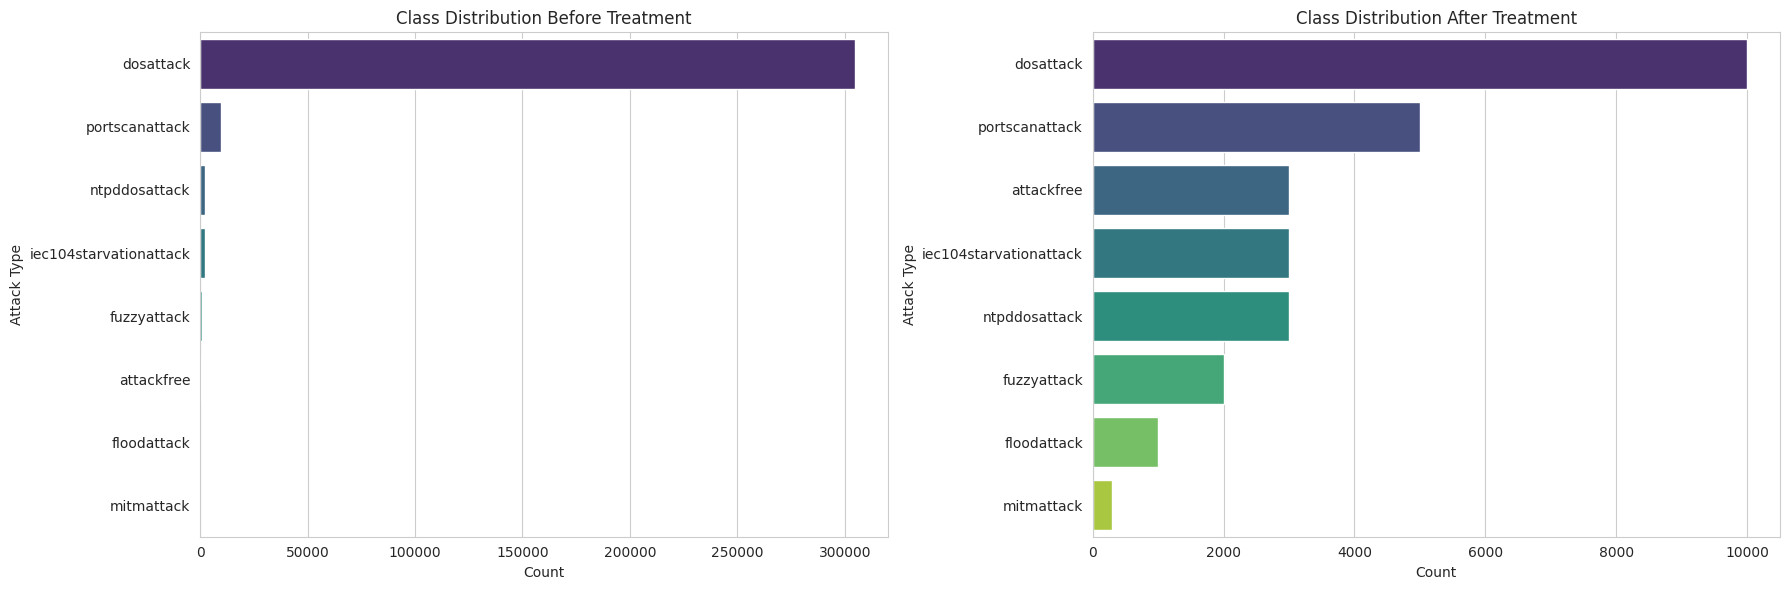

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.pipeline import Pipeline

# ==========================================
# 1. Define Paths & Load Data (Colab Paths)
#    (Copied from previous data processing cell to ensure y and y_resampled are defined)
# ==========================================
attack_dir = '/content/drive/MyDrive/ECE1513/Project/iec104_pre-processed/attack-data/'
attack_free_dir = '/content/drive/MyDrive/ECE1513/Project/iec104_pre-processed/attack-free-data/'

all_files = glob.glob(os.path.join(attack_dir, "*.csv")) + glob.glob(os.path.join(attack_free_dir, "*.csv"))

if not all_files:
    print("WARNING: No CSV files found. Please double-check your folder paths.")

df_list = [pd.read_csv(file) for file in all_files]
df = pd.concat(df_list, ignore_index=True)
df = df.dropna()

# ==========================================
# 2. Categorical Feature Encoding
#    (Copied from previous data processing cell to ensure y and y_resampled are defined)
# ==========================================
target_col = 'Label'
y = df[target_col]  # Define y (original labels)
X_raw = df.drop(columns=[target_col])

X = X_raw.copy()
categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# ==========================================
# 3. Define the Treatment Strategy
#    (Copied from previous data processing cell to ensure y and y_resampled are defined)
# ==========================================
dict_rus = {'dosattack': 10000}
dict_cc = {'portscanattack': 5000}
dict_smote = {
    'ntpddosattack': 3000,
    'iec104starvationattack': 3000,
    'attackfree': 3000,
    'floodattack': 1000
}
dict_adasyn = {'fuzzyattack': 2000}
dict_ros = {'mitmattack': 300}

treatment_pipeline = Pipeline([
    ('rus', RandomUnderSampler(sampling_strategy=dict_rus, random_state=42)),
    ('cc', ClusterCentroids(sampling_strategy=dict_cc, random_state=42)),
    ('smote', SMOTE(sampling_strategy=dict_smote, random_state=42)),
    ('adasyn', ADASYN(sampling_strategy=dict_adasyn, random_state=42)),
    ('ros', RandomOverSampler(sampling_strategy=dict_ros, random_state=42))
])

# ==========================================
# 4. Apply Treatments & Define y_resampled
#    (Copied from previous data processing cell to ensure y and y_resampled are defined)
# ==========================================
X_resampled, y_resampled = treatment_pipeline.fit_resample(X, y) # Define y_resampled (treated labels)

# ==========================================
# 5. Plotting Code
# ==========================================
# Set plot style
sns.set_style("whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Distribution before treatment
sns.countplot(y=y, ax=axes[0], order=y.value_counts().index, palette='viridis')
axes[0].set_title('Class Distribution Before Treatment')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Attack Type')

# Plot 2: Distribution after treatment
sns.countplot(y=y_resampled, ax=axes[1], order=y_resampled.value_counts().index, palette='viridis')
axes[1].set_title('Class Distribution After Treatment')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Attack Type')

plt.tight_layout()
plt.show()